# **Modélisation avec regression logistique**

# 1. Introduction:

### 🤖 Analyse de Sentiment avec Régression Logistique

#### Projet de machine learning pour la Classification des Sentiments

#### Objectif du Notebook
Ce notebook présente une approche complète de classification des sentiments utilisant la régression logistique sur un jeu de données de commentaires.

**Étapes Principales :**
- Encodage des labels
- Vectorisation des textes
- Entraînement du modèle
- Évaluation des performances

# 2. Importation des bibliothèques nécessaires

## 📚 Configuration de l'Environnement de Travail

### Importation des Bibliothèques Essentielles
- **Traitement de Données** : Pandas
- **Machine Learning** : Scikit-Learn
- **Prétraitement** : TF-IDF Vectorizer
- **Modélisation** : Régression Logistique

### Objectifs de l'Étape
- Préparer les outils nécessaires à l'analyse
- Importer les bibliothèques spécialisées
- Configurer l'environnement de modélisation

In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# 3. Chargement des Données

## 💾 Exploration et Préparation du Jeu de Données

### Source des Données
- **Fichier Source** : balanced_subset.csv
- **Contenu** : Commentaires de restaurants avec annotations de sentiment

### Étapes de Préparation
- Chargement du jeu de données complet
- Échantillonnage stratifié
- Vérification de l'équilibre des classes

### Analyse Préliminaire
- Taille du dataset
- Distribution des sentiments
- Aperçu des données brutes

3.1 Charger le jeu de données

In [6]:
# Charger le fichier CSV contenant les colonnes 'rating' et 'cleaned_text'
df = pd.read_csv('../data_csv/balanced_subset.csv', encoding='utf-8')
df.dropna(inplace=True)
df_subset = df.sample(n=400000, random_state=42)

# Vérification des données chargées
print(df_subset.head())

# Vérification de la taille du dataset
print(f"Taille du dataset : {df_subset.shape}")

           rating                                       cleaned_text
1220269  Positive  ive order mexican food spicy chicken taco fant...
3228760  Positive  ive wicked wiches twice time food awesome craf...
587369    Neutral  come mother long line outside seem new orleans...
286110    Neutral  fun interest experience coffee good bacon good...
1415670  Negative  read review website think wed give try visit t...
Taille du dataset : (400000, 2)


3.2 Vérifier l'équilibre des classes

In [3]:
group_counts = df_subset['rating'].value_counts()
print(group_counts)

rating
Negative    160172
Positive    160034
Neutral      79794
Name: count, dtype: int64


# 4. Encodage des Labels


## 🏷️ Transformation des Labels de Sentiment

### Processus de Codage
- Conversion des labels textuels en valeurs numériques
- Utilisation de LabelEncoder

### Mapping des Sentiments
- Négatif → Valeur numérique
- Neutre → Valeur numérique
- Positif → Valeur numérique

### Objectifs
- Préparer les données pour l'apprentissage automatique
- Standardiser la représentation des sentiments

In [7]:
# Encodage des labels 'rating' en valeurs numériques
label_encoder = LabelEncoder()
df_subset['rating_encoded'] = label_encoder.fit_transform(df_subset['rating'])

# Vérification des classes encodées
print(f"Classes encodées : {label_encoder.classes_}")

Classes encodées : ['Negative' 'Neutral' 'Positive']


# 5. Vectorisation des Textes avec TF-IDF


## 📊 Transformation Vectorielle des Commentaires

### Technique de Vectorisation
- **Méthode** : TF-IDF (Term Frequency-Inverse Document Frequency)
- Conversion des textes en représentation numérique

### Paramètres de Vectorisation
- Gestion des mots-vides
- Limitation du vocabulaire
- Normalisation des vecteurs

### Objectifs
- Transformer le texte brut en features exploitables
- Réduire la dimensionnalité
- Préparer les données pour la classification

5.1 Avoir le nombre maximal des mots unique


In [6]:
vectorizer = TfidfVectorizer(max_features=None)
vectorizer.fit(df_subset['cleaned_text'])
print(f"Taille du vocabulaire : {len(vectorizer.get_feature_names_out())}")

Taille du vocabulaire : 228964


5.2 Conversion des textes en vecteurs numériques

In [8]:
# Initialisation du TfidfVectorizer
# max_features=10000 limite le vocabulaire à 10000 mots les plus fréquents
tfidf_vectorizer = TfidfVectorizer(max_features=10000)

# Vectorisation des textes
X_tfidf = tfidf_vectorizer.fit_transform(df_subset['cleaned_text'])

# Séparation des features (X) et des labels (y)
X = X_tfidf
y = df_subset['rating_encoded']

# Vérification de la forme des données vectorisées
print(f"Forme des données vectorisées : {X.shape}")

Forme des données vectorisées : (400000, 10000)


# 6. Division des Données en Ensemble d'Entraînement et de Test


## 🔀 Division des Données d'Apprentissage

### Stratégie de Séparation
- **Ratio** : 80% Entraînement, 20% Test
- Stratification pour préserver la distribution des classes

### Méthode
- Utilisation de train_test_split
- Séparation des features (X) et des labels (y)

### Objectifs
- Prévenir le surapprentissage
- Permettre une évaluation indépendante
- Garantir la généralisation du modèle

In [15]:
# Division des données en ensembles d'entraînement et de test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Vérification des tailles des ensembles
print(f"Taille de l'ensemble d'entraînement : {X_train.shape}")
print(f"Taille de l'ensemble de test : {X_test.shape}")

Taille de l'ensemble d'entraînement : (320000, 10000)
Taille de l'ensemble de test : (80000, 10000)


# 7. Optimisation des hyperparamètres avec GridSearchCV

## 🔬 Optimisation des Paramètres du Modèle

### Technique de Recherche
- **Méthode** : GridSearchCV
- Exploration exhaustive des configurations

### Hyperparamètres Évalués
- Types de régularisation
- Force de régularisation
- Stratégies d'optimisation

### Approche
- Sélection du meilleur modèle
- Minimisation du risque de surapprentissage

In [16]:
# Recherche des meilleurs hyperparamètres avec GridSearchCV
param_grid = [
    # Combinaisons pour lbfgs et sag (l2 ou None)
    {
        'penalty': ['l2', None],
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['lbfgs', 'sag']
    },
    # Combinaisons pour saga (l1, l2)
    {
        'penalty': ['l1', 'l2'],
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['saga'],
    },
    # Combinaisons pour saga (elasticnet)
    {
        'penalty': ['elasticnet'],
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['saga'],
        'l1_ratio': [0.5]
    }
]

# Initialisation de GridSearchCV
grid_search = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5, n_jobs=-1, scoring='accuracy')

# Entraînement de GridSearchCV
grid_search.fit(X_train, y_train)

# Affichage des meilleurs paramètres trouvés
print(f"Meilleurs hyperparamètres : {grid_search.best_params_}")

# Prédictions avec le modèle optimal
best_logreg = grid_search.best_estimator_
y_pred_best = best_logreg.predict(X_test)

# Précision avec le meilleur modèle
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"Précision avec le meilleur modèle : {accuracy_best:.2f}")

# Rapport de classification avec le meilleur modèle
print("Rapport de classification avec le meilleur modèle:")
print(classification_report(y_test, y_pred_best, target_names=label_encoder.classes_))

# Matrice de confusion avec le meilleur modèle
print("Matrice de confusion avec le meilleur modèle:")
print(confusion_matrix(y_test, y_pred_best))


Meilleurs hyperparamètres : {'C': 1, 'penalty': 'l1', 'solver': 'saga'}
Précision avec le meilleur modèle : 0.81
Rapport de classification avec le meilleur modèle:
              precision    recall  f1-score   support

    Negative       0.84      0.89      0.87     32454
     Neutral       0.60      0.46      0.52     14794
    Positive       0.86      0.90      0.88     32752

    accuracy                           0.81     80000
   macro avg       0.77      0.75      0.76     80000
weighted avg       0.80      0.81      0.81     80000

Matrice de confusion avec le meilleur modèle:
[[28929  2393  1132]
 [ 4203  6796  3795]
 [ 1197  2082 29473]]


- Screenshot pour voir un exemple pour combien de temps m'appris pour chercher les best hyperparamters

![alt text](image.png)

# 8. Entraînement du Modèle


## 🤖 Construction du Modèle de Classification

### Algorithme
- Régression Logistique
- Classification multi-classes

### Processus d'Apprentissage
- Ajustement sur les données d'entraînement
- Minimisation de la fonction de coût
- Estimation des probabilités de classe

### Objectifs
- Modélisation prédictive des sentiments
- Généralisation des patterns appris

In [13]:
# # Récupérer les meilleurs hyperparamètres trouvés par GridSearchCV
# best_params = grid_search.best_params_

# # Initialiser le modèle avec les meilleurs hyperparamètres
best_logreg = LogisticRegression(
    penalty='l1',
    C=1,
    solver='saga',
    max_iter=1000,
    random_state=42,
    verbose=1
)

# # Si la pénalité est 'elasticnet', ajouter le paramètre l1_ratio
# if best_params['penalty'] == 'elasticnet':
#     best_logreg.set_params(l1_ratio=best_params.get('l1_ratio', 0.5))

# Récupérer les meilleurs hyperparamètres trouvés par GridSearchCV
#best_logreg = grid_search.best_estimator_

# Préparation des features et des labels
X = tfidf_vectorizer.transform(df['cleaned_text'])
y = label_encoder.transform(df['rating'])

# Séparation des données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split( X , y, test_size=0.2,random_state=42,
    stratify=y  # Conserver la distribution des classes
)

from sklearn.preprocessing import StandardScaler

# Initialisation du scaler
scaler = StandardScaler(with_mean=False)

# Appliquer l'ajustement sur les données d'entraînement et transformer
X_train = scaler.fit_transform(X_train)

# Transformer les données de test avec le même scaler (sans fit pour éviter la fuite de données)
X_test = scaler.transform(X_test)

# Entraînement du modèle avec les meilleurs hyperparamètres sur l'ensemble des données
best_logreg.fit(X_train, y_train)

print("Modèle entraîné avec succès.")

convergence after 30 epochs took 5648 seconds
Modèle entraîné avec succès.


# 9. Évaluation du modèle

## 📈 Analyse des Performances du Modèle

### Métriques d'Évaluation
- Accuracy globale
- Matrice de confusion
- Rapport de classification détaillé

### Indicateurs Clés
- Précision par classe
- Rappel
- Score F1

### Interprétation
- Forces du modèle
- Limitations identifiées
- Potentiel d'amélioration

1. Prédiction sur l'ensemble de test

In [14]:
# Prédiction sur l'ensemble de test
y_pred = best_logreg.predict(X_test)

2. Accuracy globale

In [15]:
# Calcul de la précision globale
accuracy_best = accuracy_score(y_test, y_pred)
print(f"Précision avec le meilleur modèle : {accuracy_best:.2f}")

Précision avec le meilleur modèle : 0.81


In [10]:
# Rapport de classification détaillé
print("Rapport de classification avec le meilleur modèle:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Rapport de classification avec le meilleur modèle:
              precision    recall  f1-score   support

    Negative       0.85      0.89      0.87    275995
     Neutral       0.62      0.51      0.56    137999
    Positive       0.86      0.90      0.88    276000

    accuracy                           0.82    689994
   macro avg       0.78      0.76      0.77    689994
weighted avg       0.81      0.82      0.81    689994



4. Matrice de confusion

Matrice de confusion avec le meilleur modèle:
[[245104  22949   7942]
 [ 36558  69703  31738]
 [  8040  19399 248561]]


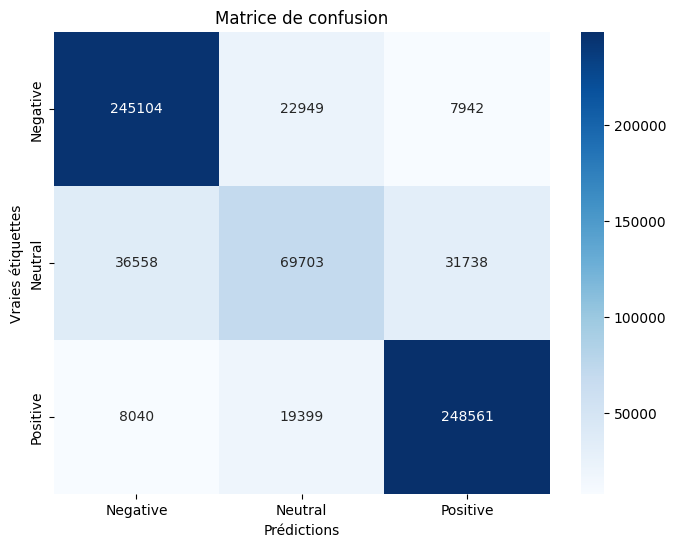

In [11]:
# Calcul et affichage de la matrice de confusion
conf_matrix = confusion_matrix(y_test, y_pred)
print("Matrice de confusion avec le meilleur modèle:")
print(conf_matrix)

# Visualisation de la matrice de confusion
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Prédictions')
plt.ylabel('Vraies étiquettes')
plt.title('Matrice de confusion')
plt.show()

5. Courbes ROC et AUC

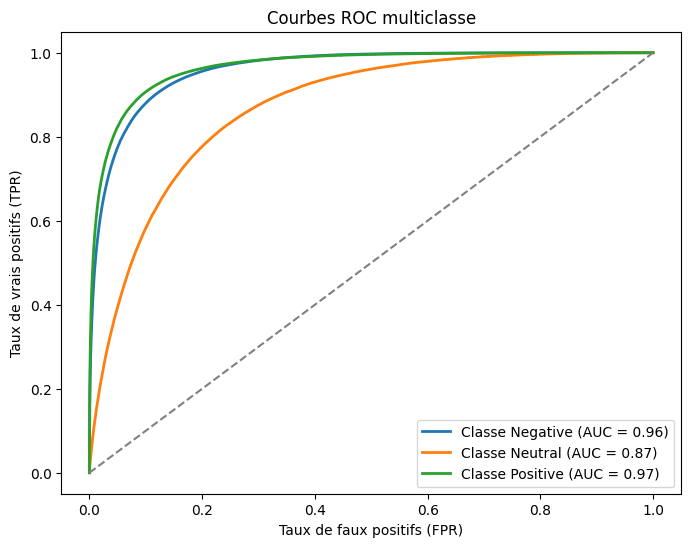

In [12]:
# Courbes ROC et AUC
# Cas multiclasse
y_pred_proba = best_logreg.predict_proba(X_test)
n_classes = len(label_encoder.classes_)
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test == i, y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], lw=2, label=f'Classe {label_encoder.classes_[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('Courbes ROC multiclasse')
plt.legend(loc='lower right')
plt.show()

6. Analyse des erreurs

In [13]:
# Analyse des erreurs (exemple avec les prédictions incorrectes)
errors = X_test[y_pred != y_test]
error_labels = y_test[y_pred != y_test]
error_predictions = y_pred[y_pred != y_test]

# Utilisation de shape[0] pour obtenir le nombre de lignes
print(f"Nombre d'erreurs : {errors.shape[0]} sur {X_test.shape[0]} prédictions")

# Afficher les 5 premières erreurs
for i in range(min(5, errors.shape[0])):  # Utilisation de shape[0] ici aussi
    print(f"Texte : {df['cleaned_text'].iloc[errors.indices[i]]}")
    print(f"Vraie étiquette : {label_encoder.classes_[error_labels[i]]}")
    print(f"Prédiction : {label_encoder.classes_[error_predictions[i]]}")
    print("---")

Nombre d'erreurs : 126626 sur 689994 prédictions
Texte : food look goodbut ordered meatloaf came charred side obvious tried cover sauce sent back literally first time ever done apology brought new piece burned didnt taste much better original piece mac cheese zero flavor half noodle even cooked didnt eat hardly meal asked wanted go box told another first place look nice good drink selection disappointed food
Vraie étiquette : Positive
Prédiction : Neutral
---
Texte : came coworkers based review food pretty good server seemed new constantly kept spilling water table even spilt phone meat guy cool one point shirt became unbuttoned flashed belly serving u meat lol
Vraie étiquette : Neutral
Prédiction : Negative
---
Texte : looking place sb two month experience spectrum best far theyre service straightforward transparent easy contact respond maintenance request promptly personally spectrum better rental rate competing realtor kind property lynn shining star customer service first pick fell

In [14]:
# Utilisation de cross_validate pour obtenir des informations supplémentaires
results = cross_validate(best_logreg, X_train, y_train, cv=5, scoring='accuracy', return_estimator=True)

# Affichage des scores et des temps
print(f"Scores de validation croisée (accuracy): {results['test_score']}")
print(f"Temps d'entraînement par fold: {results['fit_time']}")
print(f"Temps de test par fold: {results['score_time']}")
print(f"Précision moyenne de la validation croisée: {results['test_score'].mean():.2f}")

convergence after 39 epochs took 2550 seconds
convergence after 31 epochs took 24665 seconds
convergence after 32 epochs took 5072 seconds
convergence after 32 epochs took 3004 seconds
convergence after 33 epochs took 1940 seconds
Scores de validation croisée (accuracy): [0.81610522 0.81636609 0.81583167 0.81708135 0.81510669]
Temps d'entraînement par fold: [ 2551.91361213 24666.08872247  5072.86823869  3006.01087999
  1944.22251034]
Temps de test par fold: [0.22674203 0.30800724 0.42165208 0.25025225 0.36832333]
Précision moyenne de la validation croisée: 0.82


- Un petit test: 

In [15]:
# Vérification des prédictions sur quelques exemples
sample_texts = ["The food was amazing!", "Terrible service, never coming back.", "It was okay."]
sample_tfidf = tfidf_vectorizer.transform(sample_texts)
sample_predictions = best_logreg.predict(sample_tfidf)
sample_predictions_labels = label_encoder.inverse_transform(sample_predictions)

for text, label in zip(sample_texts, sample_predictions_labels):
    print(f"Texte: {text} -> Prédiction: {label}")

Texte: The food was amazing! -> Prédiction: Positive
Texte: Terrible service, never coming back. -> Prédiction: Negative
Texte: It was okay. -> Prédiction: Neutral


# 10. Sauvegarde du modèle et des transformations

## 💾 Persistance des Composants Algorithmiques

### Éléments Sauvegardés
- Modèle de Régression Logistique
- Vectoriseur TF-IDF
- Encodeur de Labels

### Objectifs
- Réutilisation future
- Déploiement dans des applications
- Reproductibilité de l'analyse

In [15]:

# Sauvegarder le modèle entraîné avec les meilleurs hyperparamètres
joblib.dump(best_logreg, 'logreg_model.pkl')

# Sauvegarde du vectorizer
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer.pkl')

# Sauvegarde du label encoder
joblib.dump(label_encoder, 'label_encoder.pkl')

['label_encoder.pkl']

# 11. Chargement du modèle sauvegardé et un exemple de prédiction

- Chargement du model

In [ ]:
# Chargement du modèle entraîné
loaded_model = joblib.load('logreg_model.pkl')

# Chargement du vectorizer
loaded_vectorizer = joblib.load('tfidf_vectorizer.pkl')

# Chargement du label encoder
loaded_label_encoder = joblib.load('label_encoder.pkl')

- Exemple :

In [24]:
# Exemple de texte pour la prédiction
example_text = ["best food"]

# Vectorisation du texte
example_tfidf = loaded_vectorizer.transform(example_text)

# Prédiction
predicted_rating = loaded_model.predict(example_tfidf)

# Décodage de la prédiction
predicted_rating_label = loaded_label_encoder.inverse_transform(predicted_rating)

print(f"Prédiction: {predicted_rating_label[0]}")

Prédiction: Positive


# 12. Conclusion:

## 🚀 Bilan et Perspectives

### Réalisations
- Modèle de classification de sentiments
- Insights sur l'analyse textuelle

### Perspectives d'Amélioration
- Enrichissement du jeu de données
- Exploration d'algorithmes avancés
- Raffinement des techniques de prétraitement

### Applications Potentielles
- Analyse de feedback client
- Systèmes de recommandation
- Veille stratégique